In [62]:
import csv
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
from scipy.stats import mannwhitneyu
from datetime import datetime, timedelta,date
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
import scipy.stats as stats
import matplotlib.pyplot as plt

# These are used for the chi-squared test and post hoc testing
from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import fisher_exact


# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 10

In [63]:
current_date = pd.to_datetime('today').date().strftime("%Y-%m-%d")


In [64]:

subjects = pd.read_csv("data/aim2_exwas_data_2024-June-11.csv")

### Calculate upper 25th percentile for 3-month house dust DEHP and determine if each measurement is above or below

In [65]:
for index, row in subjects.iterrows():
 
    dust_dehp_upper_quartile = subjects['log_dehp_bc_rec_dust_3m'].quantile(0.75)


    if str(row['log_dehp_bc_rec_dust_3m'])!='nan':
        if row['log_dehp_bc_rec_dust_3m']>dust_dehp_upper_quartile:
            subjects.loc[index,"high_dehp_dust_3m"]=1
        else:
            subjects.loc[index,"high_dehp_dust_3m"]=0

         


## Read in raw olink variable names and clean them up to make the labels publication friendly

In [ ]:
raw_olink_descriptions = pd.read_csv("raw_olink_descriptions.csv",header=None)
abbrev_to_description = {}
for index, row in raw_olink_descriptions.iterrows():
    print(row)
    try:
        description = row[0]
        data = description.split(") ")

        data2 = data[0].split(" (")
        abbrev_to_description[data2[1].replace("IL-","IL").replace("-","_")]=data2[0]
        abbrev_to_description[data2[1].replace("IL-","IL").replace("-","_")+"_5_Years"]=data2[0]+" (5 Years)"
        abbrev_to_description[data2[1].replace("IL-","IL").replace("-","_")+"_1_Year"]=data2[0]+" (1 Year)"
    except:
        print("error")


abbrev_to_description['TWEAK']="Tumor necrosis factor (Ligand) superfamily, member 12"
abbrev_to_description['TWEAK_5_Years']="Tumor necrosis factor (Ligand) superfamily, member 12"+" (5 Years)"
abbrev_to_description['TWEAK_1_Year']="Tumor necrosis factor (Ligand) superfamily, member 12"+" (1 Year)"

## Reads in more detailed Olink variable metadata

In [69]:
olink_1y_metadata = pd.read_csv("metadata/olink-1y-metadata.csv")
olink_xref_to_name={}
for index, row in olink_1y_metadata.iterrows():
    olink_xref_to_name[row['base_variable_name']]=row['short_name']

olink_5y_metadata = pd.read_csv("metadata/olink-5y-metadata.csv")
for index, row in olink_5y_metadata.iterrows():
    olink_xref_to_name[row['base_variable_name']]=row['short_name']


## Read in 1-year batch-corrected Olink NPX data

In [72]:
olink_1y_wide = pd.read_csv("data/olink-1y-variables-wide.csv")
olink_1y_wide.rename(columns=olink_xref_to_name,inplace=True)
olink_1y_wide.drop(columns=['plate_id_1_Year'],inplace=True)


In [73]:
olink_1y_wide.to_csv("data/olink-1y-variables-wide-renamed.csv",index=False)

# Read in 5-year Olink NPX data

In [74]:
olink_5y_wide = pd.read_csv("data/olink-5y-variables-wide.csv")
olink_5y_wide.rename(columns=olink_xref_to_name,inplace=True)
olink_5y_wide.drop(columns=['plate_id_5_Years'],inplace=True)



In [75]:
olink_5y_wide.to_csv("data/olink-5y-variables-wide-renamed.csv",index=False)

# Set confounders and independent variables to be tested

We chose the following cleaning/disinfectant variables as well as the binary variable indicating whether house dust DEHP levels at 3m were in the upper quartile.

'exposures' list contains variables tested with the 1-year olink data

'exposures_5y' list contains variables tested with the 5-year olink data

In [76]:
covariates = ['site_toronto', 'site_vancouver', 'site_edmonton','is_male','family_asthma_history','BF_3m','is_caucasian','prenatal_smoke_exposure','vaginal_birth','atopy_binary_1y','recurrent_wheeze_binary_1y','asthma_5y','asthma_3y','asthma_8y']
exposures = ['vitamins_supplements_3m','daily_hand_sanitizer_used_3Y','daily_hand_sanitizer_used_1y','weekly_solvent_use_by_mother_prenatal','weekly_furniture_floor_dusting_polish_use_prenatal','daily_general_disinfectant_used_prenatal','weekly_general_disinfectant_used_prenatal','one_daily_disinfectant_used_prenatal','daily_hand_sanitizer_used_prenatal','daily_hand_sanitizer_used_3m','weekly_chem_hand_cleaner_use_mother_prenatal', 'weekly_drain_cleaner_use_prenatal','weekly_or_more_bleach_use_prenatal','weekly_oven_cleaner_use_prenatal','clean_home_more_than_4_times_per_month_3m','weekly_oven_cleaner_use_3m','high_dehp_dust_3m','log_dehp_bc_rec_dust_3m']
exposures_5y = ['vitamins_supplements_3m','daily_hand_sanitizer_used_3Y','daily_hand_sanitizer_used_1y','weekly_solvent_use_by_mother_prenatal','weekly_furniture_floor_dusting_polish_use_prenatal','daily_general_disinfectant_used_prenatal','weekly_general_disinfectant_used_prenatal','one_daily_disinfectant_used_prenatal','daily_hand_sanitizer_used_prenatal','daily_hand_sanitizer_used_3m','weekly_chem_hand_cleaner_use_mother_prenatal', 'weekly_drain_cleaner_use_prenatal','weekly_or_more_bleach_use_prenatal','weekly_oven_cleaner_use_prenatal','clean_home_more_than_4_times_per_month_3m','weekly_oven_cleaner_use_3m','daily_hand_sanitizer_used_5Y','high_dehp_dust_3m','log_dehp_bc_rec_dust_3m']


In [77]:
allcolumns = ['subject_id']
allcolumns = allcolumns + covariates + exposures_5y


In [78]:
df = subjects[allcolumns]
df = pd.merge(df,olink_1y_wide,how="left", on="subject_id")
df = pd.merge(df,olink_5y_wide,how="left", on="subject_id")

# Calculate the 1-year and 5-year BMI data

In [79]:
if 1:
    anthropometric_child_health_5Y = pd.read_csv("data/anthropometric-child-health-5y-variables-wide.csv")
    anthropometric_child_health_5Y_metadata = pd.read_csv("metadata/anthropometric-child-health-5y-metadata.csv")
    anthropometric_xref_to_name = {}
    for index, row in anthropometric_child_health_5Y_metadata.iterrows():
        anthropometric_xref_to_name[row['base_variable_name']]=row['short_name'].replace("-","_")
    anthropometric_child_health_5Y.rename(columns=anthropometric_xref_to_name,inplace=True)

    anthropometric_child_health_5Y.dropna(inplace=True)
    anthropometric_child_health_5Y = anthropometric_child_health_5Y[anthropometric_child_health_5Y['child_height_cm_5_Years']!="?"]
    anthropometric_child_health_5Y['child_weight_kg_5_Years'] = anthropometric_child_health_5Y['child_weight_kg_5_Years'].astype(float)
    anthropometric_child_health_5Y['child_height_cm_5_Years'] = anthropometric_child_health_5Y['child_height_cm_5_Years'].astype(float)

    # Calculate BMI using [weight (kg) / height (cm) / height (cm)] x 10,000
    anthropometric_child_health_5Y['bmi_child_health']=(anthropometric_child_health_5Y['child_weight_kg_5_Years']/anthropometric_child_health_5Y['child_height_cm_5_Years']/anthropometric_child_health_5Y['child_height_cm_5_Years'])*10000
    anthropometric_child_health_5Y['bmi_child_health'] = round(anthropometric_child_health_5Y['bmi_child_health'],1)

In [80]:
# Add BMI from the child-anthropometric-5Y-variables-wide.cs file
anthropometric_5Y = pd.read_csv("data/child-anthropometric-5Y-variables-wide.csv")
anthropometric_5Y_metadata = pd.read_csv("metadata/child-anthropometric-metadata-5y.csv")
anthropometric_xref_to_name = {}
for index, row in anthropometric_5Y_metadata.iterrows():
    anthropometric_xref_to_name[row['base_variable_name']]=row['short_name'].replace("-","_")
anthropometric_5Y.rename(columns=anthropometric_xref_to_name,inplace=True)

# Calculate BMI using [weight (kg) / height (cm) / height (cm)] x 10,000
anthropometric_5Y['bmi_5y']=(anthropometric_5Y['child_weight_kg_5_Years']/anthropometric_5Y['child_height_cm_5_Years']/anthropometric_5Y['child_height_cm_5_Years'])*10000
anthropometric_5Y['bmi_5y'] = round(anthropometric_5Y['bmi_5y'],1)


In [81]:
anthropometric_measures_1y= pd.read_csv("data/child-anthropometric-measures-1y.csv")
anthropometric_measures_1y['bmi_1y']=(anthropometric_measures_1y['weight_kg']/anthropometric_measures_1y['length_cm']/anthropometric_measures_1y['length_cm'])*10000

In [82]:
anthropometric_5Y.drop(columns=['child_weight_kg_5_Years','child_height_cm_5_Years','head_circumference_cm_5_Years','mid_arm_circumference_cm_5_Years','hip_circumference_cm_5_Years','waist_circumference_cm_5_Years'],inplace=True)

In [83]:
df = pd.merge(df,anthropometric_5Y,how="left", on="subject_id")

In [84]:
df = pd.merge(df,anthropometric_measures_1y,how="left", on="subject_id")

# Mean differences in 1-year cytokine levels due to prenatal exposures - non-parameteric Mann-Whitney

In [85]:
# Exclude select numerical exposures because they are not appropriate for the analysis here
exposures_to_exclude = ['hours_spent_during_week_day_in_bus_van_car_3m','log_dehp_bc_rec_dust_3m','frequency_of_use_of_purell-type_hand_cleaner_3m','frequency_of_use_of_purell-type_hand_cleaner_1Y','frequency_of_use_of_purell-type_hand_cleaner_3Y','frequency_of_use_of_purell-type_hand_cleaner_5Y']

odds_ratio_table = pd.DataFrame(columns=['visit','exposure','cytokine','mean concentration (no exposure)','n (no exposure group)','mean concentration (exposure)','n (exposure group)','U1','p'])
for exposure in exposures:
    

    if exposure not in exposures_to_exclude:

        for cytokine in df.columns:
        
            if cytokine in olink_1y_wide.columns and cytokine !='subject_id' and cytokine !='plate_id_1_Year':
        
                if 1:
                    covariates_and_cytokine_list = [exposure,cytokine]
                    covariates_and_cytokine_list = covariates_and_cytokine_list + covariates


                    if 1:
                        X = df[covariates_and_cytokine_list]
                        X.dropna(inplace=True)
                        X_grouped = X.groupby(exposure).mean()[[cytokine]]
                    

                        positive_exposures = X[X[exposure]==1]
                        positive_exposures = positive_exposures[cytokine].tolist()
                    
                        # Get mean of the positive exposure group
                        positive_exposure_cytokine_series = pd.Series(positive_exposures)
                        mean_cytokine_positive_exposures = positive_exposure_cytokine_series.sum()/len(positive_exposures)
                

                        negative_exposures = X[X[exposure]==0]
                        negative_exposures = negative_exposures[cytokine].tolist()
        
                        # Get mean of the positive exposure group
                        negative_exposure_cytokine_series = pd.Series(negative_exposures)
                        mean_cytokine_negative_exposures = negative_exposure_cytokine_series.sum()/len(negative_exposures)
                

                        U1, p = mannwhitneyu(positive_exposures, negative_exposures)

                        rowdata = {}
                        rowdata['visit'] = '1 Year'
                        rowdata['exposure'] = exposure
                        rowdata['cytokine'] = cytokine
                        rowdata['mean concentration (no exposure)'] = round(mean_cytokine_negative_exposures,3)
                        rowdata['n (no exposure group)'] = len(negative_exposures)
                        rowdata['mean concentration (exposure)'] = +round(mean_cytokine_positive_exposures,3)
                        rowdata['n (exposure group)'] = len(positive_exposures)
                        rowdata['U1'] =  U1
                        rowdata['p'] = p

                        odds_ratio_table.loc[len(odds_ratio_table)] = rowdata
                        
                        
                        #print([U1,p])
                        if p<0.01:
                            print(exposure+"\t"+cytokine+"\t"+str(round(mean_cytokine_negative_exposures,3))+"\t"+str(len(negative_exposures))+"\t"+str(round(mean_cytokine_positive_exposures,3))+"\t"+str(len(positive_exposures))+"\t"+str(U1)+"\t"+str(p))
                    if 0:
                        print("Error with cytokine="+cytokine+" and exposure="+exposure)


                if 0:
                    print("Error with "+cytokine)
       
        

daily_hand_sanitizer_used_3Y	SIRT2_1_Year	5.259	419	5.696	31	8424.0	0.005764676102357224
daily_hand_sanitizer_used_3Y	STAMBP_1_Year	5.054	419	5.442	31	8655.0	0.0019915278596480098
weekly_furniture_floor_dusting_polish_use_prenatal	CCL28_1_Year	2.383	390	2.174	42	6189.0	0.009264787152741356
daily_general_disinfectant_used_prenatal	CX3CL1_1_Year	3.742	444	3.363	6	504.0	0.008917781401946797
daily_general_disinfectant_used_prenatal	NT-3_1_Year	2.336	444	1.965	6	303.0	0.0011523442721174581
weekly_general_disinfectant_used_prenatal	CD40_1_Year	11.656	371	11.84	79	17372.0	0.009632270038439398
one_daily_disinfectant_used_prenatal	TNFSF14_1_Year	6.828	395	7.181	55	13470.0	0.003912675996149264
one_daily_disinfectant_used_prenatal	SIRT2_1_Year	5.247	395	5.592	55	13309.0	0.006790616878962952
one_daily_disinfectant_used_prenatal	EN-RAGE_1_Year	6.394	395	6.897	55	13948.0	0.0006399051613465119
one_daily_disinfectant_used_prenatal	CD40_1_Year	11.66	395	11.888	55	13478.0	0.0038040347181081302
one_daily

# Multiple testing correction for p-values associated with Mann-Whitney testing (1 Year)

In [86]:
import statsmodels.stats.multitest
# Remove any nan p-values

frames = []

for exposure in exposures:
   
    for visit in ['1 Year']:

        temp = odds_ratio_table[(odds_ratio_table['exposure']==exposure) & (odds_ratio_table['visit']==visit)]
        temp = temp[temp['p'].notna()]

        if len(temp)>0:


            # Perform multiple testing to get q value
            reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['p'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
            # Adds the q-value (correct p-value) and Pass/Fail to the data frame
            temp['q']=q
            temp['reject_null']=reject
            #temp = temp[temp['reject_null']==True]
            frames.append(temp)
            temp.to_csv("cytokine-mean-differences/Mann-Whitney_"+current_date+"-"+visit+"_"+exposure+".csv",index=False)

            for index, row in temp.iterrows():
                if row['reject_null']==True:
                    print(row['exposure']+"\t"+row['cytokine']+"\t"+str(row['p'])+"\t"+str(row['q']))

daily_hand_sanitizer_used_prenatal	EN-RAGE_1_Year	0.0010314507220701217	0.046931007854190535
daily_hand_sanitizer_used_prenatal	ADA_1_Year	0.0007214692718624861	0.046931007854190535
weekly_chem_hand_cleaner_use_mother_prenatal	ST1A1_1_Year	0.00015768879730804978	0.014349680555032529


In [87]:
odds_ratio_table_corrected_for_fdr = pd.concat(frames)
#odds_ratio_table_corrected_for_fdr[odds_ratio_table_corrected_for_fdr['reject_null']==True]
odds_ratio_table_corrected_for_fdr.to_csv("~/Downloads/odds_ratio_table_corrected_for_fdr_1_year.csv")

# Mean differences in 5-year cytokine levels due to prenatal exposures - non-parameteric Mann-Whitney

In [88]:
# Exclude select numerical exposures because they are not appropriate for the analysis here
exposures_to_exclude = ['hours_spent_during_week_day_in_bus_van_car_3m','log_dehp_bc_rec_dust_3m','frequency_of_use_of_purell-type_hand_cleaner_3m','frequency_of_use_of_purell-type_hand_cleaner_1Y','frequency_of_use_of_purell-type_hand_cleaner_3Y','frequency_of_use_of_purell-type_hand_cleaner_5Y']


odds_ratio_table = pd.DataFrame(columns=['visit','exposure','cytokine','mean concentration (no exposure)','n (no exposure group)','mean concentration (exposure)','n (exposure group)','U1','p'])
for exposure in exposures_5y:


    if exposure not in exposures_to_exclude:

        for cytokine in df.columns:
        
            if cytokine in olink_5y_wide.columns and cytokine !='subject_id' and cytokine !='plate_id_5_Years':
        
                try:
                    covariates_and_cytokine_list = [exposure,cytokine]
                    covariates_and_cytokine_list = covariates_and_cytokine_list + covariates

                    X = df[covariates_and_cytokine_list]
                    X.dropna(inplace=True)
                    X_grouped = X.groupby(exposure).mean()[[cytokine]]

                    positive_exposures = X[X[exposure]==1]
                    positive_exposures = positive_exposures[cytokine].tolist()
                # print(len(positive_exposures))
                    # Get mean of the positive exposure group
                    positive_exposure_cytokine_series = pd.Series(positive_exposures)
                    mean_cytokine_positive_exposures = positive_exposure_cytokine_series.sum()/len(positive_exposures)
                    #print(mean_cytokine_positive_exposures)



                    negative_exposures = X[X[exposure]==0]
                    negative_exposures = negative_exposures[cytokine].tolist()
                    #print(len(negative_exposures))
                    # Get mean of the positive exposure group
                    negative_exposure_cytokine_series = pd.Series(negative_exposures)
                    mean_cytokine_negative_exposures = negative_exposure_cytokine_series.sum()/len(negative_exposures)
                    #print(mean_cytokine_negative_exposures)

                    U1, p = mannwhitneyu(positive_exposures, negative_exposures)

                    rowdata = {}
                    rowdata['visit'] = '5 Years'
                    rowdata['exposure'] = exposure
                    rowdata['cytokine'] = cytokine
                    rowdata['mean concentration (no exposure)'] = round(mean_cytokine_negative_exposures,3)
                    rowdata['n (no exposure group)'] = len(negative_exposures)
                    rowdata['mean concentration (exposure)'] = +round(mean_cytokine_positive_exposures,3)
                    rowdata['n (exposure group)'] = len(positive_exposures)
                    rowdata['U1'] =  U1
                    rowdata['p'] = p

                    odds_ratio_table.loc[len(odds_ratio_table)] = rowdata
                    
                    
                    #print([U1,p])
                    if p<0.01:
                        print(exposure+"\t"+cytokine+"\t"+str(round(mean_cytokine_negative_exposures,3))+"\t"+str(len(negative_exposures))+"\t"+str(round(mean_cytokine_positive_exposures,3))+"\t"+str(len(positive_exposures))+"\t"+str(U1)+"\t"+str(p))



                except:
                    print("Error with "+cytokine)
       
        
   



vitamins_supplements_3m	IL-17C_5_Years	2.712	46	2.317	218	3249.0	0.00017713365455515202
daily_hand_sanitizer_used_1y	EN-RAGE_5_Years	7.258	285	6.689	28	2792.0	0.008777652093841529
daily_hand_sanitizer_used_1y	FGF-19_5_Years	8.069	285	8.623	28	5359.0	0.002746165859127138
weekly_solvent_use_by_mother_prenatal	MMP-1_5_Years	13.792	283	14.424	14	2792.0	0.009768577905473173
daily_general_disinfectant_used_prenatal	CD8A_5_Years	9.297	309	10.251	4	1146.0	0.000734982581482802
daily_general_disinfectant_used_prenatal	MCP-3_5_Years	4.602	309	1.306	4	105.0	0.0013179305665171242
daily_general_disinfectant_used_prenatal	CASP-8_5_Years	3.69	309	2.566	4	166.0	0.007652900851046551
one_daily_disinfectant_used_prenatal	CCL4_5_Years	7.342	275	7.835	38	6575.0	0.00985950259216546
one_daily_disinfectant_used_prenatal	TNF_5_Years	2.814	275	3.106	38	6755.0	0.0034452135057707863
daily_hand_sanitizer_used_prenatal	CCL4_5_Years	7.344	278	7.865	35	6168.0	0.00984143091410214
daily_hand_sanitizer_used_prenatal	TNF_

# Multiple testing correction for 5-year Mann-Whitney test p-values

In [89]:
import statsmodels.stats.multitest
# Remove any nan p-values

frames = []

for exposure in exposures_5y:
   

    for visit in ['5 Years']:

        temp = odds_ratio_table[(odds_ratio_table['exposure']==exposure) & (odds_ratio_table['visit']==visit)]
        temp = temp[temp['p'].notna()]

        if len(temp)>0:


            # Perform multiple testing to get q value
            reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['p'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
            # Adds the q-value (correct p-value) and Pass/Fail to the data frame
            temp['q']=q
            temp['reject_null']=reject
            #temp = temp[temp['reject_null']==True]
            frames.append(temp)
            temp.to_csv("cytokine-mean-differences/Mann-Whitney_"+current_date+"-"+visit+"_"+exposure+".csv",index=False)

            for index, row in temp.iterrows():
                if row['reject_null']==True:
                    print(row['exposure']+"\t"+row['cytokine']+"\t"+str(row['p'])+"\t"+str(row['q']))

vitamins_supplements_3m	IL-17C_5_Years	0.00017713365455515202	0.016119162564518834
clean_home_more_than_4_times_per_month_3m	IL4_5_Years	0.0003850947555156373	0.03504362275192299


In [90]:
odds_ratio_table_corrected_for_fdr = pd.concat(frames)
#odds_ratio_table_corrected_for_fdr[odds_ratio_table_corrected_for_fdr['reject_null']==True]
odds_ratio_table_corrected_for_fdr.to_csv("~/Downloads/odds_ratio_table_corrected_for_fdr_5_year.csv")
odds_ratio_table_corrected_for_fdr

,visit,exposure,cytokine,mean concentration (no exposure),n (no exposure group),mean concentration (exposure),n (exposure group),U1,p,q,reject_null
0,5 Years,vitamins_supplements_3m,VEGFA_5_Years,11.320,46,11.321,218,5028.0,0.977114,0.987971,False
1,5 Years,vitamins_supplements_3m,CD8A_5_Years,9.351,46,9.299,218,4650.0,0.439854,0.967904,False
2,5 Years,vitamins_supplements_3m,MCP-3_5_Years,4.467,46,4.723,218,5390.0,0.424905,0.967904,False
3,5 Years,vitamins_supplements_3m,GDNF_5_Years,1.182,46,1.258,218,5800.0,0.095079,0.967904,False
4,5 Years,vitamins_supplements_3m,CDCP1_5_Years,1.489,46,1.474,218,4724.0,0.538429,0.967904,False
...,...,...,...,...,...,...,...,...,...,...,...
1633,5 Years,high_dehp_dust_3m,STAMBP_5_Years,4.596,58,4.614,24,729.0,0.740479,0.920071,False
1634,5 Years,high_dehp_dust_3m,IL5_5_Years,0.863,58,1.018,24,657.0,0.694787,0.920071,False
1635,5 Years,high_dehp_dust_3m,ADA_5_Years,5.572,58,5.581,24,740.0,0.657531,0.920071,False
1636,5 Years,high_dehp_dust_3m,TNFB_5_Years,5.552,58,5.467,24,579.0,0.235112,0.920071,False


## Significant 1-year cytokine levels associated with daily hand sanitizer being used (prenatal) 

### Mann-Whitney

In [91]:
daily_hand_sanitizer_prenatal_df = pd.read_csv("cytokine-mean-differences/Mann-Whitney_2024-10-23-1 Year_daily_hand_sanitizer_used_prenatal.csv")
daily_hand_sanitizer_prenatal_df = daily_hand_sanitizer_prenatal_df[daily_hand_sanitizer_prenatal_df['reject_null']==True]
for index, row in daily_hand_sanitizer_prenatal_df.iterrows():
    cytokine = row['cytokine'].replace("_5_Years","")
    daily_hand_sanitizer_prenatal_df.loc[index,'cytokine']=cytokine
daily_hand_sanitizer_prenatal_df.drop(columns=['visit','exposure','U1','reject_null'],inplace=True)
daily_hand_sanitizer_prenatal_df.to_csv("manuscript/signficant_1_year_cytokines_daily_hand_sanitizer_prenatal.csv",index=False)
daily_hand_sanitizer_prenatal_df

,cytokine,mean concentration (no exposure),n (no exposure group),mean concentration (exposure),n (exposure group),p,q
34,TNFSF14_1_Year,6.831,399,7.189,51,0.002335,0.042493
69,EN-RAGE_1_Year,6.398,399,6.904,51,0.000516,0.023466
70,CD40_1_Year,11.661,399,11.903,51,0.001318,0.029975
78,CASP-8_1_Year,3.191,399,3.684,51,0.001045,0.029975
88,ADA_1_Year,5.754,399,5.978,51,0.000361,0.023466


### Generates figure comparing unadjusted 1-year level of ADA due to daily hand sanitizer use (prenatal)

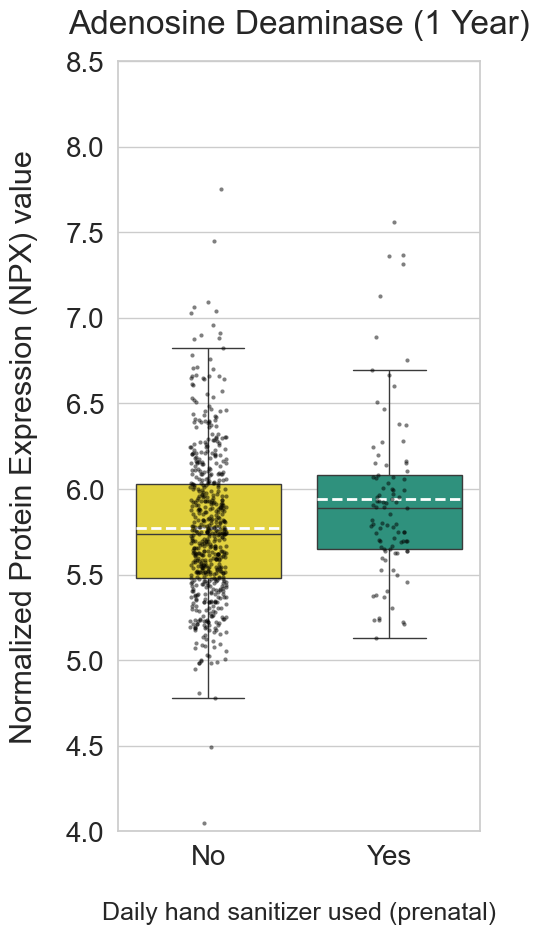

In [92]:
tmp = df[~df['ADA_1_Year'].isna()]
#tmp = tmp[tmp['asthma_5y']==1]
tmp = tmp[~tmp['daily_hand_sanitizer_used_prenatal'].isna()]
plt.figure(figsize=(5,10))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Define a custom grey color palette
palette = ["#fde725", "#1fa187"]

# Add the title to the figure
plt.title(abbrev_to_description['ADA_1_Year'], fontsize=24, pad=20)  # Adjust the font size and title text here


# Create a mapping for x-axis labels
x_labels = {0: "No", 1: "Yes"}
plt.ylim(4,8.5)
ax = sns.boxplot(data=tmp, y="ADA_1_Year", x="daily_hand_sanitizer_used_prenatal", showfliers=False,palette=palette, showmeans=True,meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
# Overlay the data points with transparency
sns.stripplot(data=tmp, y="ADA_1_Year", x="daily_hand_sanitizer_used_prenatal", color="black", alpha=0.5, size=3)

# Set x-axis labels
plt.xticks([0, 1], [x_labels[0], x_labels[1]])

# Set x-axis title and increase font size
ax.set_xlabel("Daily hand sanitizer used (prenatal)", fontsize=18,labelpad=22)  # Adjust the font size here

# Increase y-axis label font size
ax.set_ylabel("Normalized Protein Expression (NPX) value", fontsize=22, labelpad=20)  # Adjust the font size here

# Adjust the figure's right margin to move the y-axis label to the right
plt.subplots_adjust(right=0.85)  # Adjust the value as needed

# Increase y-axis tick label font size
ax.tick_params(axis='y', labelsize=20)  # Adjust the font size here

# Increase x-axis tick label font size
ax.tick_params(axis='x', labelsize=20)  # Adjust the font size here


plt.savefig('cytokine-mean-differences/ADA_daily_hand_sanitizer_used_prenatal.png')
plt.show()

### Multiple linear regression of daily prenatal hand sanitizer use on ADA, while adjusting for other confounders

In [93]:
odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','abbrev','cytokine','exposure','total children','Beta','Lower CI', 'Upper CI','P-value'])

### Unadjusted model

In [94]:
# Fit linear regression model here
temp = df.copy()
#temp = temp[temp['asthma_5y']==1]
model = sm.formula.ols('ADA_1_Year ~ daily_hand_sanitizer_used_prenatal', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["daily_hand_sanitizer_used_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="ADA_1_Year"
significant_effect_row['cytokine']="Adenosine deaminase"
significant_effect_row['exposure']="Daily HS (prenatal)"
significant_effect_row['time outcome assessed']="1 year"


significant_effect_row['total children']=len(temp[~temp["ADA_1_Year"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:             ADA_1_Year   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     11.51
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000731
Time:                        13:03:55   Log-Likelihood:                -404.22
No. Observations:                 670   AIC:                             812.4
Df Residuals:                     668   BIC:                             821.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

### Adjusted model controlling for confounders

In [95]:
# Fit linear regression model here
temp = df.copy()

model = sm.formula.ols('ADA_1_Year ~ daily_hand_sanitizer_used_prenatal +  is_male + site_toronto + site_edmonton + site_vancouver + bmi_1y + BF_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["daily_hand_sanitizer_used_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="ADA_1_Year"
significant_effect_row['cytokine']="Adenosine deaminase"
significant_effect_row['exposure']="Daily HS (prenatal) + covariates"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["ADA_1_Year"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:             ADA_1_Year   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     7.047
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.98e-08
Time:                        13:03:55   Log-Likelihood:                -384.59
No. Observations:                 668   AIC:                             785.2
Df Residuals:                     660   BIC:                             821.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

### Adjusted model controlling for confounders and effects of 3-month and 1-year daily hand sanitizer use

In [96]:
# Fit linear regression model here
temp = df.copy()

model = sm.formula.ols('ADA_1_Year ~ daily_hand_sanitizer_used_prenatal + daily_hand_sanitizer_used_3m +  daily_hand_sanitizer_used_1y + is_male + site_toronto + site_edmonton + site_vancouver + bmi_1y + BF_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["daily_hand_sanitizer_used_prenatal"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="ADA_1_Year"
significant_effect_row['cytokine']="Adenosine deaminase"
significant_effect_row['exposure']="Daily HS (prenatal) + covariates + Daily HS (3m) + Daily HS (1y)"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["ADA_1_Year"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:             ADA_1_Year   R-squared:                       0.073
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     5.792
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           8.95e-08
Time:                        13:03:55   Log-Likelihood:                -383.20
No. Observations:                 668   AIC:                             786.4
Df Residuals:                     658   BIC:                             831.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

### Final results

In [97]:
odds_ratio_table

,time outcome assessed,abbrev,cytokine,exposure,total children,Beta,Lower CI,Upper CI,P-value
0,1 year,ADA_1_Year,Adenosine deaminase,Daily HS (prenatal),670,0.17,0.07,0.27,0.0007
1,1 year,ADA_1_Year,Adenosine deaminase,Daily HS (prenatal) + covariates,670,0.15,0.05,0.24,0.0030
2,1 year,ADA_1_Year,Adenosine deaminase,Daily HS (prenatal) + covariates + Daily HS (3...,670,0.17,0.06,0.27,0.0014


In [98]:
from matplotlib.ticker import FuncFormatter

# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

# SUPPLEMENTARY FIGURES 8a and 8b - Daily prenatal hand sanitizer association with adenosine deaminase

(-0.1, 0.6)

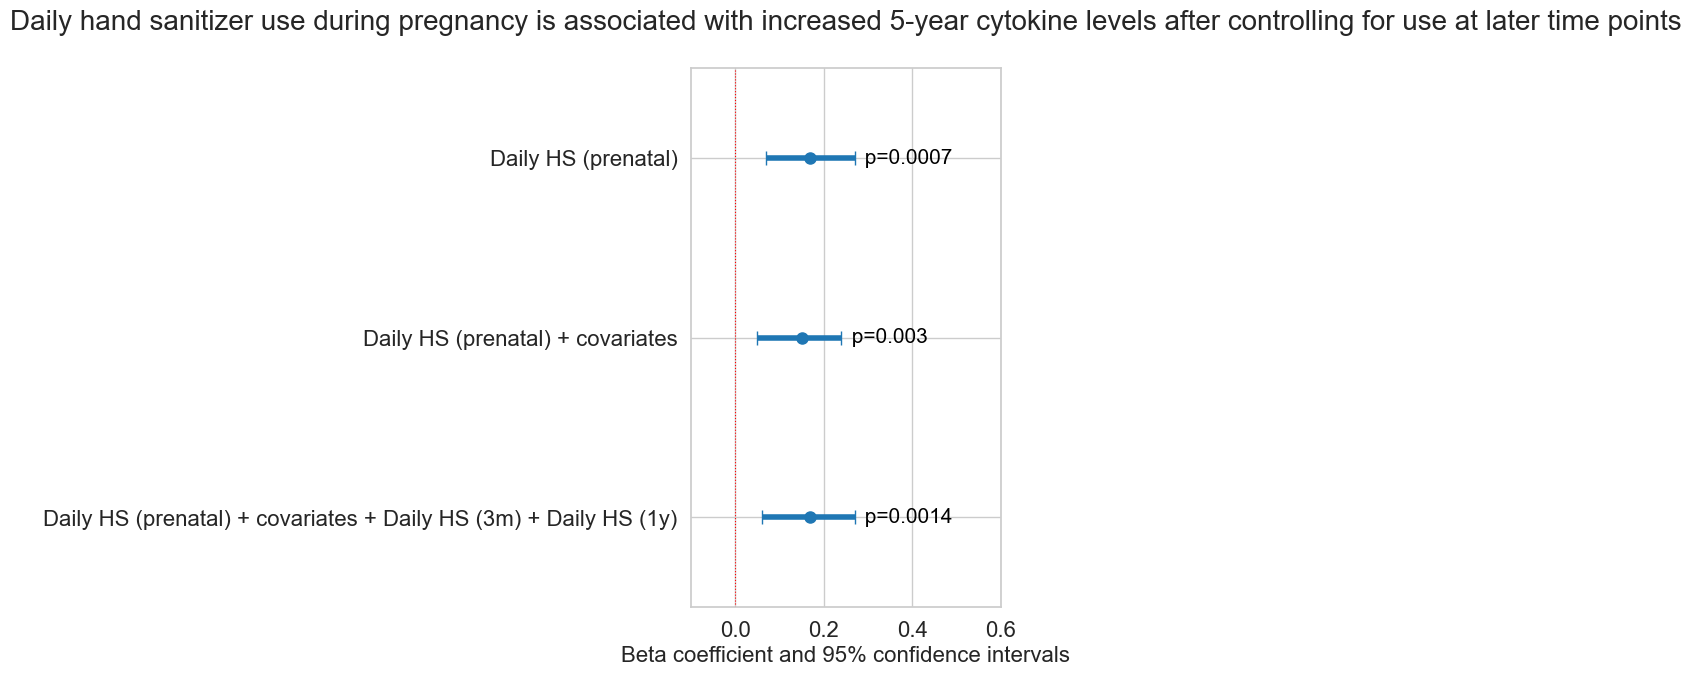

In [99]:
odds_ratio_table = odds_ratio_table.sort_values(by="exposure")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(4,7))
plt.title("Daily hand sanitizer use during pregnancy is associated with increased 5-year cytokine levels after controlling for use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='1 year':
        ci = [[row['Beta'] - row['Lower CI']], [row['Upper CI'] - row['Beta']]]
        if 1:
            label = str(row['Beta'])
         
            plt.errorbar(x=[row['Beta']], y=[row['exposure']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            #label = "* p="+str(row['P-value'])
            label = " p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['Beta'] + ci[1][0] + 0.01, row['exposure'], f'{label}', color='black', va='center', fontsize=15)



#plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
#ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=0, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Beta coefficient and 95% confidence intervals', fontsize=16)
ax.set_ylim(-0.5, 2.5)
plt.xlim(-0.1,0.6)

# Home cleaned more than 4 times per month (birth-3m)

## Mann-Whitney results summary

In [100]:
clean_home_more_than_4_times_per_month_df = pd.read_csv("cytokine-mean-differences/Mann-Whitney_2024-10-23-1 Year_clean_home_more_than_4_times_per_month_3m.csv")
clean_home_more_than_4_times_per_month_df = clean_home_more_than_4_times_per_month_df[clean_home_more_than_4_times_per_month_df['reject_null']==True]
for index, row in clean_home_more_than_4_times_per_month_df.iterrows():
    cytokine = row['cytokine'].replace("_5_Years","")
    clean_home_more_than_4_times_per_month_df.loc[index,'cytokine']=cytokine
clean_home_more_than_4_times_per_month_df.drop(columns=['visit','exposure','U1','reject_null'],inplace=True)
clean_home_more_than_4_times_per_month_df.to_csv("manuscript/signficant_1_year_cytokines_clean_home_more_than_4_times_per_month_3m.csv",index=False)
clean_home_more_than_4_times_per_month_df

,cytokine,mean concentration (no exposure),n (no exposure group),mean concentration (exposure),n (exposure group),p,q
45,IL-18R1_1_Year,8.08,360,8.223,82,0.000501,0.045587


# SUPPLEMENTARY FIGURE 10a: unadjusted differences in 1-year IL18R1 due to cleaning homes more than 4 times per month

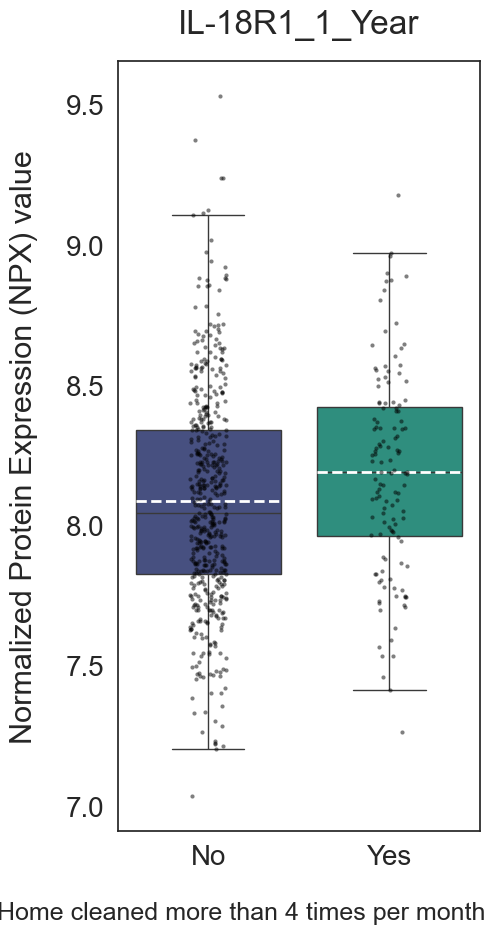

In [101]:
sns.set_theme(style="white")

tmp = df[~df['IL-18R1_1_Year'].isna()]
#tmp = tmp[tmp['asthma_5y']==1]
tmp = tmp[~tmp['clean_home_more_than_4_times_per_month_3m'].isna()]
plt.figure(figsize=(5,10))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Define a custom color palette
palette = [ "#3e4989","#1f9e89"]

# Add the title to the figure
plt.title('IL-18R1_1_Year', fontsize=24, pad=20)  # Adjust the font size and title text here


# Create a mapping for x-axis labels
x_labels = {0: "No", 1: "Yes"}
#plt.ylim(1.5,5)
ax = sns.boxplot(data=tmp, y="IL-18R1_1_Year", x="clean_home_more_than_4_times_per_month_3m", showfliers=False,palette=palette, showmeans=True,meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
# Overlay the data points with transparency
sns.stripplot(data=tmp, y="IL-18R1_1_Year", x="clean_home_more_than_4_times_per_month_3m", color="black", alpha=0.5, size=3)

# Set x-axis labels
plt.xticks([0, 1], [x_labels[0], x_labels[1]])

# Set x-axis title and increase font size
ax.set_xlabel("Home cleaned more than 4 times per month (birth-3m)", fontsize=18,labelpad=22)  # Adjust the font size here

# Increase y-axis label font size
ax.set_ylabel("Normalized Protein Expression (NPX) value", fontsize=22, labelpad=20)  # Adjust the font size here

# Adjust the figure's right margin to move the y-axis label to the right
plt.subplots_adjust(right=0.85)  # Adjust the value as needed

# Increase y-axis tick label font size
ax.tick_params(axis='y', labelsize=20)  # Adjust the font size here

# Increase x-axis tick label font size
ax.tick_params(axis='x', labelsize=20)  # Adjust the font size here


plt.savefig('cytokine-mean-differences/ADA_1_Year_daily_disinfectant.png')
plt.show()

### Significant 5-year cytokine differences due to cleaning homes more than 4 times per month based on Mann-Whitney test 

In [102]:
clean_home_more_than_4_times_per_month_df = pd.read_csv("cytokine-mean-differences/Mann-Whitney_2024-10-23-5 Years_clean_home_more_than_4_times_per_month_3m.csv")
clean_home_more_than_4_times_per_month_df = clean_home_more_than_4_times_per_month_df[clean_home_more_than_4_times_per_month_df['reject_null']==True]
for index, row in clean_home_more_than_4_times_per_month_df.iterrows():
    cytokine = row['cytokine'].replace("_5_Years","")
    clean_home_more_than_4_times_per_month_df.loc[index,'cytokine']=cytokine
clean_home_more_than_4_times_per_month_df.drop(columns=['visit','exposure','U1','reject_null'],inplace=True)
clean_home_more_than_4_times_per_month_df.to_csv("manuscript/signficant_5_year_cytokines_clean_home_more_than_4_times_per_month_3m.csv",index=False)
clean_home_more_than_4_times_per_month_df

,cytokine,mean concentration (no exposure),n (no exposure group),mean concentration (exposure),n (exposure group),p,q
61,Flt3L,8.219,256,8.410,52,0.000921,0.041911
74,IL4,0.371,256,0.561,52,0.000193,0.017522


### Differences in 5-year IL4 due to cleaning home more than 4 times per month

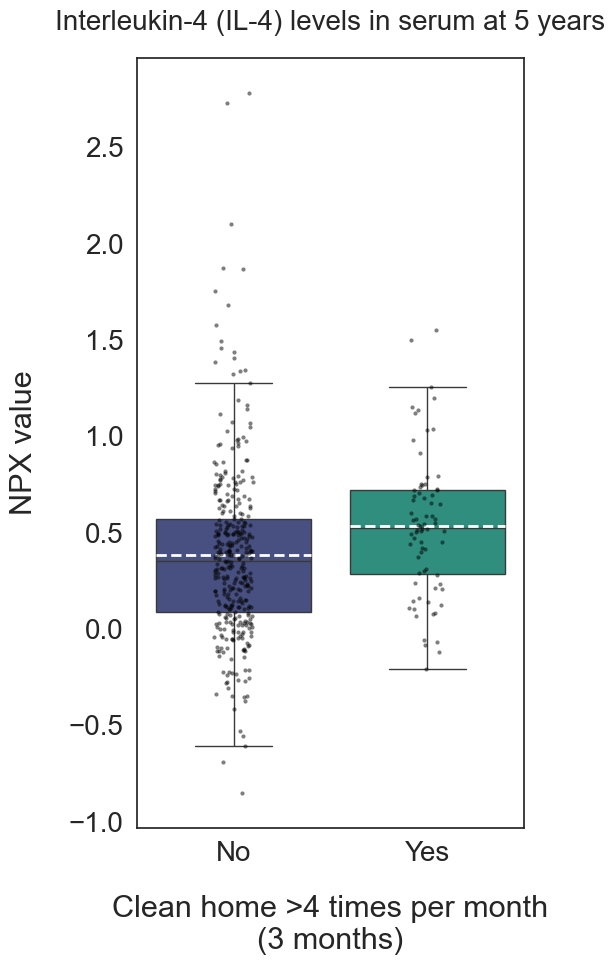

In [103]:
tmp = df[~df['IL4_5_Years'].isna()]
tmp = tmp[~tmp['clean_home_more_than_4_times_per_month_3m'].isna()]
plt.figure(figsize=(5,10))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'


# Define a custom grey color palette
palette = [ "#3e4989","#1f9e89"]

# Add the title to the figure
plt.title("Interleukin-4 (IL-4) levels in serum at 5 years", fontsize=20, pad=20)  # Adjust the font size and title text here


# Create a mapping for x-axis labels
x_labels = {0: "No", 1: "Yes"}

#plt.ylim(0,3.5)

ax = sns.boxplot(data=tmp, y="IL4_5_Years", x="clean_home_more_than_4_times_per_month_3m", showfliers=False,palette=palette,showmeans=True, meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
# Overlay the data points with transparency
sns.stripplot(data=tmp, y="IL4_5_Years", x="clean_home_more_than_4_times_per_month_3m", color="black", alpha=0.5, size=3)

# Set x-axis labels
plt.xticks([0, 1], [x_labels[0], x_labels[1]])

# Set x-axis title and increase font size
ax.set_xlabel("Clean home >4 times per month\n(3 months)", fontsize=22, labelpad=20)  # Adjust the font size here

# Increase y-axis label font size
ax.set_ylabel("NPX value", fontsize=22, labelpad=22)  # Adjust the font size here

# Increase y-axis tick label font size
ax.tick_params(axis='y', labelsize=20)  # Adjust the font size here

# Increase x-axis tick label font size
ax.tick_params(axis='x', labelsize=20)  # Adjust the font size here
plt.savefig('cytokine-mean-differences/IL4_5_Years_clean_home_more_than_4_times_per_month_3m.png')
plt.show()

### Differences in 5-year Flt3L due to cleaning home more than 4 times per month

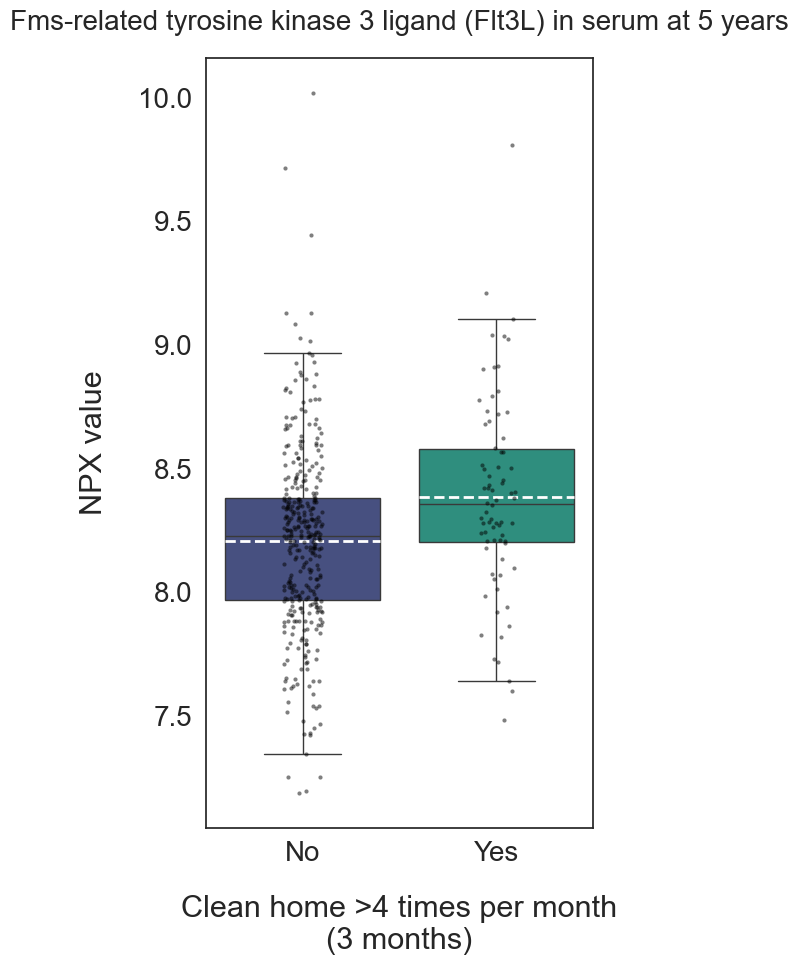

In [104]:
tmp = df[~df['Flt3L_5_Years'].isna()]
tmp = tmp[~tmp['clean_home_more_than_4_times_per_month_3m'].isna()]
plt.figure(figsize=(5,10))

# Set the font family to Arial
plt.rcParams['font.family'] = 'Arial'

# Add the title to the figure
plt.title("Fms-related tyrosine kinase 3 ligand (Flt3L) in serum at 5 years", fontsize=20, pad=20)  # Adjust the font size and title text here


# Create a mapping for x-axis labels
x_labels = {0: "No", 1: "Yes"}

#plt.ylim(0,3.5)

ax = sns.boxplot(data=tmp, y="Flt3L_5_Years", x="clean_home_more_than_4_times_per_month_3m", showfliers=False,palette=palette, showmeans=True,meanline=True, meanprops={'color': 'white', 'ls': '--', 'lw': 2})
# Overlay the data points with transparency
sns.stripplot(data=tmp, y="Flt3L_5_Years", x="clean_home_more_than_4_times_per_month_3m", color="black", alpha=0.5, size=3)

# Set x-axis labels
plt.xticks([0, 1], [x_labels[0], x_labels[1]])

# Set x-axis title and increase font size
ax.set_xlabel("Clean home >4 times per month\n(3 months)", fontsize=22, labelpad=20)  # Adjust the font size here


# Increase y-axis label font size
ax.set_ylabel("NPX value", fontsize=22, labelpad=22)  # Adjust the font size here

# Increase y-axis tick label font size
ax.tick_params(axis='y', labelsize=20)  # Adjust the font size here

# Increase x-axis tick label font size
ax.tick_params(axis='x', labelsize=20)  # Adjust the font size here
plt.savefig('cytokine-mean-differences/Flt3L_5_Years_clean_home_more_than_4_times_per_month_3m.png')
plt.show()

## Multiple linear regression of 1-year IL18R1, and 5-year Flt3L and IL4

For each cytokine, create one unadjusted model and one model that adjusts for confounders

Return beta coefficients to demonstrate effect

In [105]:
odds_ratio_table = pd.DataFrame(columns=['time outcome assessed','abbrev','cytokine','exposure','total children','Beta','Lower CI', 'Upper CI','P-value'])

### 1-year IL-18R1 (unadjusted)

In [106]:
# Fit linear regression model here
temp = df.copy()
temp = temp.rename(columns={"IL-18R1_1_Year":"IL18R1_1_Year"})

model = sm.formula.ols('IL18R1_1_Year ~ clean_home_more_than_4_times_per_month_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["clean_home_more_than_4_times_per_month_3m"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="IL18R1_1_Year"
significant_effect_row['cytokine']="IL-18R1 (1 year)"
significant_effect_row['exposure']="Clean home more than 4 times per month"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["IL18R1_1_Year"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:          IL18R1_1_Year   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     7.685
Date:                Mon, 27 Apr 2026   Prob (F-statistic):            0.00573
Time:                        13:03:56   Log-Likelihood:                -293.77
No. Observations:                 657   AIC:                             591.5
Df Residuals:                     655   BIC:                             600.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### 1-year IL-18R1 (adjusted for confounders)

In [107]:
# Fit linear regression model here
temp = df.copy()
temp = temp.rename(columns={"IL-18R1_1_Year":"IL18R1_1_Year"})

model = sm.formula.ols('IL18R1_1_Year ~ clean_home_more_than_4_times_per_month_3m + is_male + site_toronto + site_edmonton + site_vancouver + bmi_1y + BF_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["clean_home_more_than_4_times_per_month_3m"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="IL18R1_1_Year"
significant_effect_row['cytokine']="IL-18R1 (1 year) - adjusted"
significant_effect_row['exposure']="Clean home more than 4 times per month"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["IL18R1_1_Year"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:          IL18R1_1_Year   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     3.790
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000484
Time:                        13:03:56   Log-Likelihood:                -284.02
No. Observations:                 655   AIC:                             584.0
Df Residuals:                     647   BIC:                             619.9
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### 5-year IL4 (unadjusted)

In [108]:
# Fit linear regression model here
temp = df.copy()


model = sm.formula.ols('IL4_5_Years ~ clean_home_more_than_4_times_per_month_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["clean_home_more_than_4_times_per_month_3m"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="IL4_5_Years"
significant_effect_row['cytokine']="IL-4 (5 years)"
significant_effect_row['exposure']="Clean home more than 4 times per month"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["IL4_5_Years"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:            IL4_5_Years   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     6.894
Date:                Mon, 27 Apr 2026   Prob (F-statistic):            0.00896
Time:                        13:03:56   Log-Likelihood:                -260.14
No. Observations:                 429   AIC:                             524.3
Df Residuals:                     427   BIC:                             532.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### 5-year IL4 (adjusted for covariates)

In [109]:
# Fit linear regression model here
temp = df.copy()


model = sm.formula.ols('IL4_5_Years ~ clean_home_more_than_4_times_per_month_3m + is_male + site_toronto + site_edmonton + site_vancouver + bmi_1y + BF_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["clean_home_more_than_4_times_per_month_3m"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="IL4_5_Years"
significant_effect_row['cytokine']="IL-4 (5 years) - adjusted"
significant_effect_row['exposure']="Clean home more than 4 times per month"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["IL4_5_Years"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:            IL4_5_Years   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.974
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0572
Time:                        13:03:56   Log-Likelihood:                -256.25
No. Observations:                 428   AIC:                             528.5
Df Residuals:                     420   BIC:                             561.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### 5-year Flt3L (unadjusted)

In [110]:
# Fit linear regression model here
temp = df.copy()


model = sm.formula.ols('Flt3L_5_Years ~ clean_home_more_than_4_times_per_month_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["clean_home_more_than_4_times_per_month_3m"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="Flt3L_5_Years"
significant_effect_row['cytokine']="Flt3L (5 years)"
significant_effect_row['exposure']="Clean home more than 4 times per month"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["Flt3L_5_Years"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:          Flt3L_5_Years   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     13.00
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           0.000348
Time:                        13:03:56   Log-Likelihood:                -195.61
No. Observations:                 429   AIC:                             395.2
Df Residuals:                     427   BIC:                             403.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

### 5-year Flt3l (adjusted for confounders)

In [111]:
# Fit linear regression model here
temp = df.copy()


model = sm.formula.ols('Flt3L_5_Years ~ clean_home_more_than_4_times_per_month_3m + is_male + site_toronto + site_edmonton + site_vancouver + bmi_1y + BF_3m', data=temp).fit()

# Print model summary
print(model.summary())

odds_ratios = pd.DataFrame(
    {
        "Beta": model.params,
        "Lower CI": model.conf_int()[0],
        "Upper CI": model.conf_int()[1]
    }
)
#odds_ratios = np.exp(odds_ratios)

odds_ratios['P-value'] = round(model.pvalues,4)
odds_ratios[odds_ratios['P-value']<0.05]
odds_ratios['Lower CI'] = round(odds_ratios['Lower CI'],2)
odds_ratios['Upper CI'] = round(odds_ratios['Upper CI'],2)
odds_ratios['Beta'] = round(odds_ratios['Beta'],2)
odds_ratios = odds_ratios.loc["clean_home_more_than_4_times_per_month_3m"]    


significant_effect_row = odds_ratios.to_dict()
                        

significant_effect_row['abbrev']="Flt3L_5_Years"
significant_effect_row['cytokine']="Flt3L (5 years) - adjusted"
significant_effect_row['exposure']="Clean home more than 4 times per month"
significant_effect_row['time outcome assessed']="1 year"

significant_effect_row['total children']=len(temp[~temp["Flt3L_5_Years"].isna()])
odds_ratio_table.loc[len(odds_ratio_table)] = significant_effect_row

                            OLS Regression Results                            
Dep. Variable:          Flt3L_5_Years   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     4.567
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           6.23e-05
Time:                        13:03:56   Log-Likelihood:                -186.34
No. Observations:                 428   AIC:                             388.7
Df Residuals:                     420   BIC:                             421.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------

# SUPPLEMENTARY FIGURE 10b - Forest plot for adjusted associatios between daily prenatal hand sanitizer use and IL-18R1, IL4 and Flt3L (5 year serum)

(-0.1, 0.5)

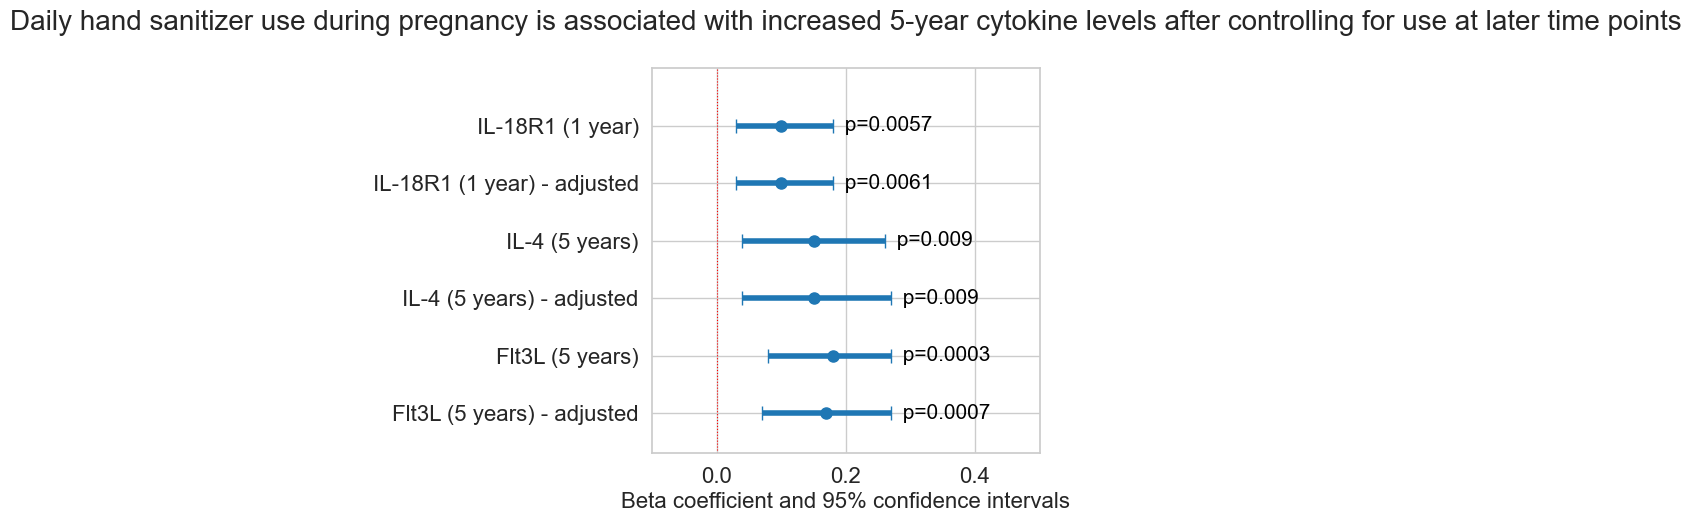

In [112]:
#odds_ratio_table = odds_ratio_table.sort_values(by="cytokine")

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(5,5))
plt.title("Daily hand sanitizer use during pregnancy is associated with increased 5-year cytokine levels after controlling for use at later time points\n",fontsize=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():
    if row['time outcome assessed']=='1 year':
        ci = [[row['Beta'] - row['Lower CI']], [row['Upper CI'] - row['Beta']]]
        if 1:
            label = str(row['Beta'])
         
            plt.errorbar(x=[row['Beta']], y=[row['cytokine']], xerr=ci, ecolor='tab:blue', capsize=5, linestyle='None', linewidth=4, marker="o", markersize=8, mfc="tab:blue", mec="tab:blue")
       
            #label = "* p="+str(row['P-value'])
            label = " p="+str(row['P-value'])
            # Add text to the right of the error bar
            plt.text(row['Beta'] + ci[1][0] + 0.01, row['cytokine'], f'{label}', color='black', va='center', fontsize=15)



#plt.xscale('log',basex=10)
# Apply the custom tick label formatting function
#ax.xaxis.set_major_formatter(FuncFormatter(log_fmt))
ax.xaxis.grid(True, which='minor', linestyle=':', linewidth='0.5', color='black')
        
plt.axvline(x=0, linewidth=0.8, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlabel('Beta coefficient and 95% confidence intervals', fontsize=16)
ax.set_ylim(-0.7, 6)
plt.xlim(-0.1,0.5)